# GTSRB: CNN-3 vs CNN-5 in TensorFlow and PyTorch

**Author:** Nguyễn Văn Trường (B23DCCE095) · E23CNPM02 · Intelligent System Development · Assignment 05

**GTSRB** (German Traffic Sign Recognition Benchmark, IJCNN 2011) is a collection of 51,839 traffic-sign photographs
captured from a moving vehicle, resized to 32×32 color, spanning **43 classes** (speed limits, stop, yield, priority
road, and more). Source: Kaggle
[`harbhajansingh21/german-traffic-sign-dataset`](https://www.kaggle.com/datasets/harbhajansingh21/german-traffic-sign-dataset).

Why this dataset is challenging: 43 distinct classes with as much as a 10× gap in image count between them, photos
that are frequently dark or blurred, and signs that look almost identical (e.g. "speed limit 30" versus "80").

| Run ID | Framework | Model |
|---|---|---|
| `GT-TF-CNN-3` | TensorFlow/Keras | 3 convolutional layers |
| `GT-TF-CNN-5` | TensorFlow/Keras | 5 convolutional layers |
| `GT-PT-CNN-3` | PyTorch | 3 convolutional layers |
| `GT-PT-CNN-5` | PyTorch | 5 convolutional layers |

The method is covered in sections 1–5, while sections 6–7 present and discuss the results.


## 1. Setup

A fixed seed of 42 is applied everywhere, so weight initialization, batch ordering and dropout stay identical across
reruns. PyTorch picks its device in the order `cuda` → `mps` → `cpu`; TensorFlow automatically uses an NVIDIA GPU
(on Linux/WSL2) or an Apple GPU when available, falling back to CPU otherwise. Because TensorFlow only reserves GPU
memory as it needs it, PyTorch is free to share the same GPU. Setting `A5_SMOKE=1` triggers a fast smoke-test run.


In [1]:
import copy
import time
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


SEED = 42
warnings.filterwarnings("ignore", category=UserWarning)

import tensorflow as tf
import keras
from keras import layers

keras.utils.set_random_seed(SEED)

import torch
import torch.nn as nn

torch.manual_seed(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available()
                      else "mps" if torch.backends.mps.is_available() else "cpu")

print("TensorFlow", tf.__version__, "| GPUs:", tf.config.list_physical_devices("GPU"))
print("PyTorch", torch.__version__, "| device:", DEVICE)

TensorFlow 2.21.0 | GPUs: []
PyTorch 2.14.0+cpu | device: cpu


**Helper functions** (nothing model-specific here): resolving project paths, the stored data split, test-set
metrics, result files and plotting. Settings both frameworks share: batch size 256, up to 20 epochs, early-stopping
patience of 3, learning rate 0.001.


In [2]:
import json
import os
import random
from pathlib import Path

from sklearn.metrics import (accuracy_score, average_precision_score, confusion_matrix, f1_score,
                             precision_score, recall_score, roc_auc_score)
from sklearn.model_selection import train_test_split

SMOKE = os.environ.get("A5_SMOKE") == "1"          # fast smoke test: tiny subsample, 2 epochs


def find_root():
    """assignment_05/ is the nearest ancestor of the working directory that contains dataset/ and notebook/."""
    here = Path.cwd().resolve()
    for p in [here, *here.parents]:
        if (p / "dataset").is_dir() and (p / "notebook").is_dir():
            return p
    return here.parent


ROOT = find_root()
DATA_DIR = Path(os.environ.get("A5_DATA_DIR", ROOT / "dataset"))
RESULTS_DIR = ROOT / "notebook" / "results" / ("smoke" if SMOKE else "")
MODELS_DIR = ROOT / "notebook" / "models" / ("smoke" if SMOKE else "")
FIG_DIR = ROOT / "report" / "images" / ("smoke" if SMOKE else "")
for d in (RESULTS_DIR, MODELS_DIR, FIG_DIR):
    d.mkdir(parents=True, exist_ok=True)

BATCH_SIZE = 256
EPOCHS = 2 if SMOKE else 20
PATIENCE = 3
LEARNING_RATE = 1e-3
SMOKE_SIZE = {"train": 2000, "validation": 500, "test": 500}

random.seed(SEED)
np.random.seed(SEED)
print("project folder:", ROOT, "| smoke run:", SMOKE, "| epochs:", EPOCHS, "| batch size:", BATCH_SIZE)


def find_file(code, name):
    """Locate `name` anywhere below dataset/<code>/ (unzipping sometimes nests it inside a subfolder)."""
    base = DATA_DIR / code.lower()
    hits = sorted(base.rglob(name))
    if not hits:
        raise FileNotFoundError(f"{name} not found under {base}; see dataset/README.md")
    return hits[0]


def make_or_load_splits(code, y, n_sample=None):
    """Build (or reuse) a stratified 70/15/15 split of row indices, cached at dataset/<code>/splits.npz."""
    path = DATA_DIR / code.lower() / "splits.npz"
    n_sample = min(n_sample or len(y), len(y))
    splits = None
    if path.exists():
        saved = np.load(path)
        splits = {k: saved[k] for k in ("train", "validation", "test")}
        if sum(len(v) for v in splits.values()) != n_sample:
            splits = None
    if splits is None:
        idx = np.arange(len(y))
        if n_sample < len(y):
            idx, _ = train_test_split(idx, train_size=n_sample, stratify=y, random_state=SEED)
        train, rest = train_test_split(idx, train_size=0.70, stratify=y[idx], random_state=SEED)
        val, test = train_test_split(rest, test_size=0.50, stratify=y[rest], random_state=SEED)
        splits = {"train": np.sort(train), "validation": np.sort(val), "test": np.sort(test)}
        np.savez(path, **splits)
    if SMOKE:
        rng = np.random.default_rng(SEED)
        splits = {k: np.sort(rng.choice(v, min(SMOKE_SIZE[k], len(v)), replace=False)) for k, v in splits.items()}
    return splits


def classification_metrics(y_true, y_pred, y_score=None, binary=False):
    """Accuracy plus macro precision/recall/F1; binary tasks also get positive-class F1, ROC-AUC and AP."""
    m = {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision_macro": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "recall_macro": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "f1_macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
    }
    if binary:
        m["f1_positive"] = f1_score(y_true, y_pred, pos_label=1, zero_division=0)
        m["roc_auc"] = roc_auc_score(y_true, y_score)
        m["average_precision"] = average_precision_score(y_true, y_score)
    return {k: float(v) for k, v in m.items()}


class Stopwatch:
    def __enter__(self):
        self._start = time.perf_counter()
        return self

    def __exit__(self, *exc):
        self.seconds = time.perf_counter() - self._start


def save_result(record):
    (RESULTS_DIR / f"{record['run_id']}.json").write_text(json.dumps(record, indent=2), encoding="utf-8")


def load_results(run_ids):
    paths = [RESULTS_DIR / f"{rid}.json" for rid in run_ids]
    return [json.loads(p.read_text(encoding="utf-8")) for p in paths if p.exists()]


def savefig(fig, name):
    fig.savefig(FIG_DIR / f"{name}.png", dpi=150, bbox_inches="tight")


def plot_history(history, run_id):
    """Two-panel figure: loss and accuracy per epoch, train curve against validation curve."""
    fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
    epochs = np.arange(1, len(history["loss"]) + 1)
    for ax, key, title in [(axes[0], "loss", "Loss"), (axes[1], "accuracy", "Accuracy")]:
        ax.plot(epochs, history[key], marker="o", label="train")
        ax.plot(epochs, history[f"val_{key}"], marker="o", label="validation")
        ax.set_title(f"{run_id}: {title}"); ax.set_xlabel("epoch"); ax.grid(alpha=0.3); ax.legend()
    fig.tight_layout(); savefig(fig, f"{run_id}_curves"); plt.show()


def plot_confusion(y_true, y_pred, labels, run_id):
    """Row-normalized confusion matrix: each row is a true class, each column a predicted class."""
    cm = confusion_matrix(y_true, y_pred, labels=np.arange(len(labels)))
    shown = cm / cm.sum(axis=1, keepdims=True).clip(min=1)
    many = len(labels) > 12
    size = max(4.5, 0.28 * len(labels))
    fig, ax = plt.subplots(figsize=(size + 1, size))
    im = ax.imshow(shown, cmap="Purples", vmin=0, vmax=1)
    ax.set_xticks(range(len(labels))); ax.set_yticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=90 if many else 0, fontsize=7 if many else 9)
    ax.set_yticklabels(labels, fontsize=7 if many else 9)
    if not many:
        for i in range(len(labels)):
            for j in range(len(labels)):
                ax.text(j, i, f"{shown[i, j]:.2f}", ha="center", va="center", fontsize=8,
                        color="white" if shown[i, j] > 0.5 else "black")
    ax.set_xlabel("predicted class"); ax.set_ylabel("true class")
    ax.set_title(f"{run_id}: confusion matrix (row-normalized)")
    fig.colorbar(im, ax=ax, fraction=0.046)
    fig.tight_layout(); savefig(fig, f"{run_id}_confusion"); plt.show()
    return cm


def results_table(records):
    rows = []
    for r in records:
        row = {"run_id": r["run_id"], "framework": r["framework"], "model": r["model"], "params": r["params"],
               "epochs": r["epochs_run"], "time_per_epoch_s": r["time_per_epoch_s"],
               "train_time_s": r["train_time_s"], "inference_ms_per_1k": r["inference_ms_per_1k"]}
        row.update(r["test_metrics"])
        rows.append(row)
    return pd.DataFrame(rows).set_index("run_id")


project folder: E:\CODING\IS_AI\intelligent_system_assignments\assignment_05 | smoke run: False | epochs: 20 | batch size: 256


Each run gets an id of the form `<dataset>-<framework>-<model>`, which names its result files and figures.


In [3]:
DATASET = "GT"
MODELS = ["CNN-3", "CNN-5"]
FRAMEWORKS = ["TF", "PT"]
RUN_IDS = [f"{DATASET}-{fw}-{m}" for fw in FRAMEWORKS for m in MODELS]
RUN_IDS

['GT-TF-CNN-3', 'GT-TF-CNN-5', 'GT-PT-CNN-3', 'GT-PT-CNN-5']

## 2. Data

### 2.1 Load

The data comes as three Python pickle files (`train.p`, `valid.p`, `test.p`), each holding a dictionary:

| Key | Shape | Content |
|---|---|---|
| `features` | `(N, 32, 32, 3)` | images, `uint8` 0–255 (already height, width, color) |
| `labels` | `(N,)` | class id 0–42 |

`signname.csv` maps each class id to a human-readable name, e.g. `14 → Stop`. A few files were pickled under
Python 2, so opening them requires `encoding="latin1"`.


In [4]:
import pickle


def load_pickle(name):
    with open(find_file(DATASET, name), "rb") as f:
        try:
            return pickle.load(f)
        except UnicodeDecodeError:          # this copy was pickled under Python 2
            f.seek(0)
            return pickle.load(f, encoding="latin1")


parts = [load_pickle(name) for name in ["train.p", "valid.p", "test.p"]]
X_raw = np.concatenate([p["features"] for p in parts]).astype(np.uint8)    # (N, 32, 32, 3)
y_raw = np.concatenate([p["labels"] for p in parts]).astype(np.int64)

sign_names = pd.read_csv(find_file(DATASET, "signname.csv")).sort_values("ClassId")
CLASS_NAMES = sign_names["SignName"].tolist()
CLASS_LABELS = [str(i) for i in range(len(CLASS_NAMES))]     # charts show the numeric id; names live in the table
print("X_raw:", X_raw.shape, "| y_raw:", y_raw.shape, "| classes:", len(CLASS_NAMES))
sign_names.set_index("ClassId").T


X_raw: (51839, 32, 32, 3) | y_raw: (51839,) | classes: 43


ClassId,0,1,2,3,4,5,6,7,8,9,...,33,34,35,36,37,38,39,40,41,42
SignName,Speed limit (20km/h),Speed limit (30km/h),Speed limit (50km/h),Speed limit (60km/h),Speed limit (70km/h),Speed limit (80km/h),End of speed limit (80km/h),Speed limit (100km/h),Speed limit (120km/h),No passing,...,Turn right ahead,Turn left ahead,Ahead only,Go straight or right,Go straight or left,Keep right,Keep left,Roundabout mandatory,End of no passing,End of no passing by vehicles over 3.5 metric


### 2.2 Split 70 / 15 / 15

All three files are combined and re-split, with **stratification** by class. This matters because a class holding
only ~250 images in total would otherwise land around ~37 test images by proportion; without stratification, random
chance could give it noticeably fewer.

The train split (70%) updates the weights, the validation split (15%) decides when training stops, and the test
split (15%) provides the final score. Row indices for each split are saved to `dataset/gt/splits.npz` and reused by
both TensorFlow and PyTorch.


In [5]:
splits = make_or_load_splits(DATASET, y_raw)
X_train, y_train = X_raw[splits["train"]], y_raw[splits["train"]]
X_val, y_val = X_raw[splits["validation"]], y_raw[splits["validation"]]
X_test, y_test = X_raw[splits["test"]], y_raw[splits["test"]]
N_CLASSES = len(CLASS_NAMES)

sizes = pd.Series({"train": len(y_train), "validation": len(y_val), "test": len(y_test)})
pd.DataFrame({"samples": sizes, "share": (sizes / sizes.sum()).round(3)})

,samples,share
train,36287,0.70
validation,7776,0.15
test,7776,0.15


### 2.3 Scale and layout

- `x / 255`: maps `0 → 0.0` and `255 → 1.0`; this rescaling happens per batch, so images remain `uint8` in memory
  otherwise.
- Keras expects `(N, 32, 32, 3)` while PyTorch expects `(N, 3, 32, 32)` — identical values, just with the axes
  reordered.


In [6]:
def to_channels_first(x):
    """Reorders (N, H, W, C) into (N, C, H, W) for PyTorch; values stay uint8."""
    return np.ascontiguousarray(np.transpose(x, (0, 3, 1, 2)))

X_train_pt, X_val_pt, X_test_pt = (to_channels_first(x) for x in (X_train, X_val, X_test))
INPUT_SHAPE_TF = X_train.shape[1:]      # (H, W, C)
INPUT_CHANNELS = X_train.shape[-1]      # C
print("TF layout:", X_train.shape, "| PT layout:", X_train_pt.shape, "| dtype:", X_train.dtype)


TF layout: (36287, 32, 32, 3) | PT layout: (36287, 3, 32, 32) | dtype: uint8


## 3. Look at the data

**Images per class.** GTSRB is heavily **unbalanced**: frequent signs such as speed limits have far more examples
than rare warning signs. The cell below reports the ratio between the largest and smallest class.

This matters because accuracy simply counts images, letting large classes dominate the score. **Macro F1**, by
contrast, averages the 43 per-class F1 scores with equal weight, so a rare sign the model never gets right will
drag it down (illustrated in section 4.6).


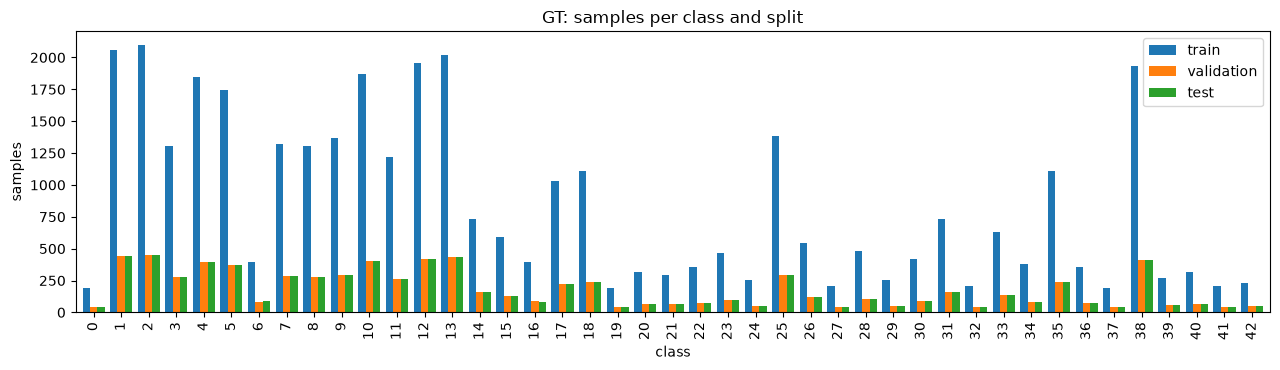

smallest class: 0 (189) | largest class: 2 (2100) | largest / smallest = 11.1


In [7]:
counts = pd.DataFrame({name: np.bincount(y_raw[idx], minlength=N_CLASSES) for name, idx in splits.items()},
                      index=CLASS_LABELS)
fig, ax = plt.subplots(figsize=(max(8, N_CLASSES * 0.3), 3.8))
counts.plot.bar(ax=ax, width=0.8)
ax.set_xlabel("class"); ax.set_ylabel("samples"); ax.set_title(f"{DATASET}: samples per class and split")
fig.tight_layout(); savefig(fig, f"{DATASET}_class_distribution"); plt.show()

train_counts = counts["train"]
print(f"smallest class: {train_counts.idxmin()} ({train_counts.min()}) | largest class: {train_counts.idxmax()} "
      f"({train_counts.max()}) | largest / smallest = {train_counts.max() / train_counts.min():.1f}")

**Samples.** A single training image is shown for each class, labeled `id: name`. Signs are distinguished by their **shape** (circle, triangle, octagon), **border color**, and the **symbol** they contain.


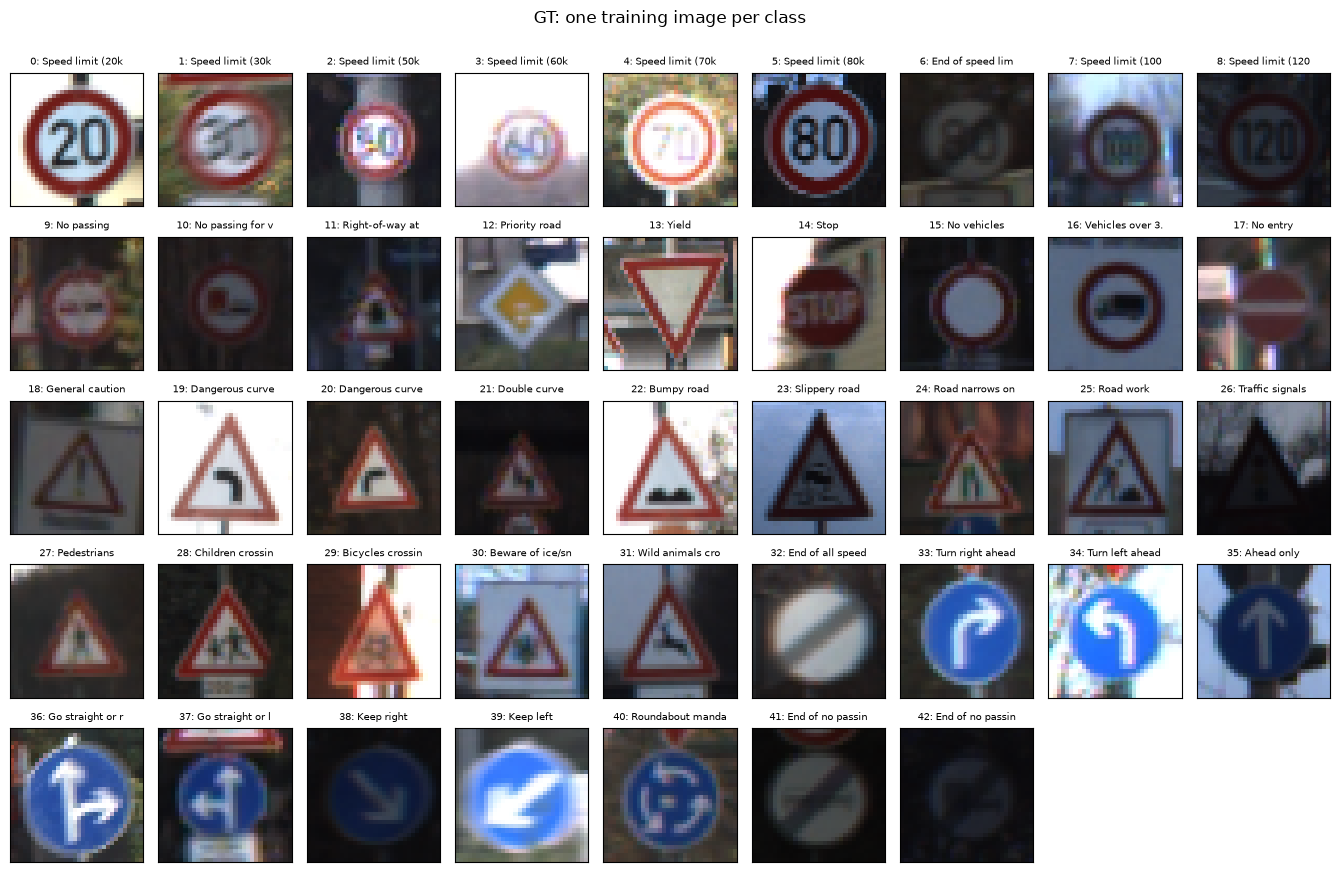

In [8]:
cols = 9
rows = int(np.ceil(N_CLASSES / cols))
fig, axes = plt.subplots(rows, cols, figsize=(cols * 1.5, rows * 1.75))
rng = np.random.default_rng(SEED)
for c, ax in enumerate(axes.ravel()):
    ax.set_xticks([]); ax.set_yticks([])
    if c >= N_CLASSES:
        ax.axis("off")
        continue
    ax.imshow(X_train[rng.choice(np.where(y_train == c)[0])])
    ax.set_title(f"{c}: {CLASS_NAMES[c][:16]}", fontsize=7)
fig.suptitle(f"{DATASET}: one training image per class", y=1.0)
fig.tight_layout(); savefig(fig, f"{DATASET}_samples"); plt.show()

**Pixel values and brightness.** A large share of GTSRB photos are quite dark, taken at dusk or in shadow. The brightness histogram illustrates how wide that spread really is; BatchNorm (section 4.2) is one way of compensating for it.


,mean,std
red,0.340,0.271
green,0.313,0.260
blue,0.323,0.268


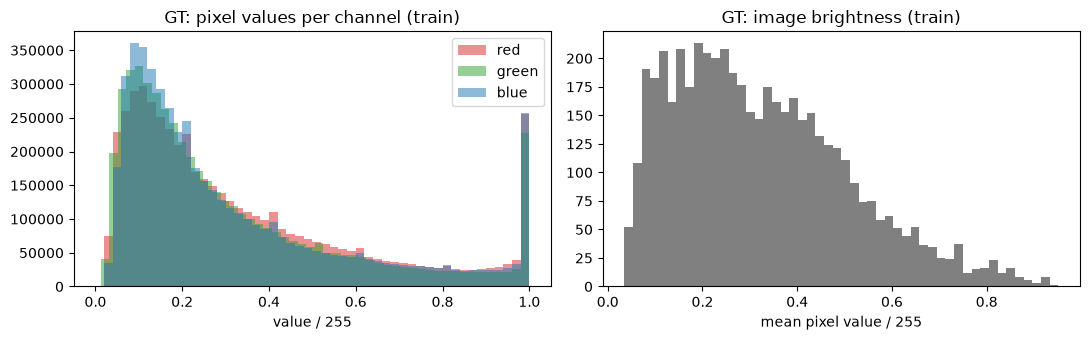

In [9]:
rng = np.random.default_rng(SEED)
sub = X_train[rng.choice(len(X_train), min(5000, len(X_train)), replace=False)].astype(np.float32) / 255.0
channel_names = ["red", "green", "blue"]
display(pd.DataFrame({"mean": sub.mean(axis=(0, 1, 2)), "std": sub.std(axis=(0, 1, 2))}, index=channel_names).round(3))

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
for ch, color in enumerate(["tab:red", "tab:green", "tab:blue"]):
    axes[0].hist(sub[..., ch].ravel(), bins=50, alpha=0.5, color=color, label=channel_names[ch])
axes[0].set_title(f"{DATASET}: pixel values per channel (train)"); axes[0].set_xlabel("value / 255"); axes[0].legend()
axes[1].hist(sub.mean(axis=(1, 2, 3)), bins=50, color="gray")
axes[1].set_title(f"{DATASET}: image brightness (train)"); axes[1].set_xlabel("mean pixel value / 255")
fig.tight_layout(); savefig(fig, f"{DATASET}_pixel_stats"); plt.show()

## 4. TensorFlow / Keras

### 4.1 Input pipeline

Built with `tf.data`: shuffle (training set only) → batch of 256 → divide by 255 → prefetch. Each batch yields
`(256, 32, 32, 3)` images with `(256,)` labels.


In [10]:
AUTOTUNE = tf.data.AUTOTUNE


def scale(x, y):
    return tf.cast(x, tf.float32) / 255.0, y


def make_tf_dataset(x, y, training):
    ds = tf.data.Dataset.from_tensor_slices((x, y))
    if training:
        ds = ds.shuffle(len(x), seed=SEED, reshuffle_each_iteration=True)
    return ds.batch(BATCH_SIZE).map(scale, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)


train_ds = make_tf_dataset(X_train, y_train, training=True)
val_ds = make_tf_dataset(X_val, y_val, training=False)
test_ds = make_tf_dataset(X_test, y_test, training=False)
train_ds.element_spec

(TensorSpec(shape=(None, 32, 32, 3), dtype=tf.float32, name=None),
 TensorSpec(shape=(None,), dtype=tf.int64, name=None))

### 4.2 One conv block on a sign edge

A conv block chains **Conv → BatchNorm → ReLU → MaxPool**. As an illustration, take the diagonal edge of a
triangular warning sign, represented as a 5×5 patch (1 = sign, 0 = background), together with a diagonal-edge
filter:

```
patch          filter
1 0 0 0 0       0 -1 -1
1 1 0 0 0       1  0 -1
1 1 1 0 0       1  1  0
1 1 1 1 0
1 1 1 1 1
```

- **Convolution** `out = Σ (window × filter) + bias`:
  - the window sitting on the diagonal `[[1,0,0],[1,1,0],[1,1,1]]` gives row sums `0 + 1 + 2 = 3`, a strong response
  - a window fully inside the sign (all 1s) sums the filter to `0`, producing no response
- **ReLU** `= max(0, x)`: leaves `3` untouched while zeroing out any negative value.
- **MaxPool 2×2**: keeps the largest of 4 values, e.g. `[[3, 0], [3, 3]] → 3`, so the edge stays detectable even at
  half the resolution.
- **BatchNorm**, applied per channel across the batch: `(x − μ) / σ`, followed by `γ·x̂ + β`.
  For a batch that mixes dark and bright pixels, `[0.05, 0.10, 0.80, 0.90]` (μ = 0.46, σ = 0.39) turns into
  `[−1.06, −0.93, 0.87, 1.12]`: the following layer therefore always sees values centered near 0 with unit spread,
  regardless of lighting.

The next cell reproduces this by hand with NumPy and checks it against `tf.nn.conv2d`.


In [11]:
patch = np.tril(np.ones((5, 5), dtype=np.float32))                   # diagonal edge of a triangular sign
kernel = np.array([[0, -1, -1], [1, 0, -1], [1, 1, 0]], dtype=np.float32)

conv = np.array([[np.sum(patch[i:i + 3, j:j + 3] * kernel) for j in range(3)] for i in range(3)])
tf_conv = tf.nn.conv2d(patch[None, :, :, None], kernel[:, :, None, None], strides=1, padding="VALID")[0, :, :, 0]
print("convolution (by hand):\n", conv)
print("same as tf.nn.conv2d:", np.allclose(conv, tf_conv.numpy()))
print("ReLU:\n", np.maximum(0, conv))

batch = np.array([0.05, 0.10, 0.80, 0.90])
print("BatchNorm of", batch, "->", ((batch - batch.mean()) / np.sqrt(batch.var() + 1e-5)).round(2))


convolution (by hand):
 [[3. 3. 1.]
 [1. 3. 3.]
 [0. 1. 3.]]
same as tf.nn.conv2d: True
ReLU:
 [[3. 3. 1.]
 [1. 3. 3.]
 [0. 1. 3.]]
BatchNorm of [0.05 0.1  0.8  0.9 ] -> [-1.06 -0.93  0.87  1.12]


### 4.3 The CNN-3 model

This cell assembles CNN-3 from three conv blocks (Conv → BatchNorm → ReLU → MaxPool) followed by a small
classification head.

| Layer | Computation | Shape (one sign) |
|---|---|---|
| Input | pixels / 255 | 32×32×3 |
| Conv 3×3, 32 filters | each position: Σ(3×3×3 window × weights) + bias | 32×32×32 |
| BatchNorm | (x − μ)/σ · γ + β, e.g. [1, 3, 5] → [−1.22, 0, 1.22] | 32×32×32 |
| ReLU | max(0, x): −1.3 → 0, 0.8 → 0.8 | 32×32×32 |
| MaxPool 2×2 | largest of 4: [[0.1, 0.9], [0.4, 0.2]] → 0.9 | 16×16×32 |
| Blocks 2, 3 | same, with 64 then 128 filters | 8×8×64 → 4×4×128 |
| GAP | mean of each 4×4 map → one number | 128 |
| Dropout 0.3 | in training, 30% of values set to 0 | 128 |
| Dense 256 → Dense 43 | 43 scores (logits), one per sign class | 43 |

- `padding="same"` pads with zeros around the border, keeping 32×32 unchanged after every Conv.
- Conv parameters follow (3·3·C_in + 1)·F, e.g. the first layer gives (3·3·3 + 1)·32 = 896.
- **CNN-5** shares this design, except blocks 1 and 2 each run two Convs before pooling (32, 32 and then 64, 64).
  Output shapes match CNN-3's, but the final unit's receptive field covers 28×28 input pixels rather than 22×22.

The following cell feeds one real sign through every layer and reports each resulting shape.


In [12]:
ARCH = {  # each entry is (number of filters, whether a max-pool follows this conv)
    "CNN-3": [(32, True), (64, True), (128, True)],
    "CNN-5": [(32, False), (32, True), (64, False), (64, True), (128, True)],
}
HEAD_UNITS = 256
DROPOUT = 0.3


def conv_block_tf(x, filters, pool):
    x = layers.Conv2D(filters, 3, padding="same")(x)
    x = layers.BatchNormalization(momentum=0.9, epsilon=1e-5)(x)
    x = layers.ReLU()(x)
    if pool:
        x = layers.MaxPooling2D(2)(x)
    return x


def build_tf(model_name, input_shape, n_classes):
    inputs = keras.Input(shape=input_shape)
    x = inputs
    for filters, pool in ARCH[model_name]:
        x = conv_block_tf(x, filters, pool)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(DROPOUT)(x)
    x = layers.Dense(HEAD_UNITS, activation="relu")(x)
    outputs = layers.Dense(n_classes)(x)            # raw class scores (logits)
    return keras.Model(inputs, outputs, name=f"{DATASET}_TF_{model_name.replace('-', '')}")


In [13]:
image = X_train[:1].astype(np.float32) / 255.0          # a single training image, kept as a batch of 1
for m in MODELS:
    model = build_tf(m, INPUT_SHAPE_TF, N_CLASSES)
    x, rows = image, []
    for layer in model.layers[1:]:
        x = layer(x, training=False)
        rows.append((layer.__class__.__name__, tuple(x.shape[1:]), layer.count_params()))
    print(f"{m}: one image through every layer")
    display(pd.DataFrame(rows, columns=["layer", "output shape", "params"]).T)


CNN-3: one image through every layer


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
layer,Conv2D,BatchNormalization,ReLU,MaxPooling2D,Conv2D,BatchNormalization,ReLU,MaxPooling2D,Conv2D,BatchNormalization,ReLU,MaxPooling2D,GlobalAveragePooling2D,Dropout,Dense,Dense
output shape,"(32, 32, 32)","(32, 32, 32)","(32, 32, 32)","(16, 16, 32)","(16, 16, 64)","(16, 16, 64)","(16, 16, 64)","(8, 8, 64)","(8, 8, 128)","(8, 8, 128)","(8, 8, 128)","(4, 4, 128)","(128,)","(128,)","(256,)","(43,)"
params,896,128,0,0,18496,256,0,0,73856,512,0,0,0,0,33024,11051


CNN-5: one image through every layer


,0,1,2,3,4,5,6,7,8,9,...,12,13,14,15,16,17,18,19,20,21
layer,Conv2D,BatchNormalization,ReLU,Conv2D,BatchNormalization,ReLU,MaxPooling2D,Conv2D,BatchNormalization,ReLU,...,ReLU,MaxPooling2D,Conv2D,BatchNormalization,ReLU,MaxPooling2D,GlobalAveragePooling2D,Dropout,Dense,Dense
output shape,"(32, 32, 32)","(32, 32, 32)","(32, 32, 32)","(32, 32, 32)","(32, 32, 32)","(32, 32, 32)","(16, 16, 32)","(16, 16, 64)","(16, 16, 64)","(16, 16, 64)",...,"(16, 16, 64)","(8, 8, 64)","(8, 8, 128)","(8, 8, 128)","(8, 8, 128)","(4, 4, 128)","(128,)","(128,)","(256,)","(43,)"
params,896,128,0,9248,128,0,0,18496,256,0,...,0,0,73856,512,0,0,0,0,33024,11051


### 4.4 Parameters

- Conv layers contribute `(K·K·C_in + 1)·F` parameters, e.g. the first layer gives `(3·3·3 + 1)·32 = 896`.
- BatchNorm adds `2·F` trainable parameters (γ, β).
- Dense layers contribute `(inputs + 1)·units`; the 43-way output layer alone accounts for `(256 + 1)·43 = 11,051`.
- Pooling, ReLU and dropout add no parameters.

Section 5's PyTorch models are checked against these same totals.


In [14]:
def expected_params(model_name, in_channels, n_classes):
    rows, c = [], in_channels
    for i, (f, _) in enumerate(ARCH[model_name], start=1):
        rows.append((f"conv{i}", f"(3·3·{c} + 1)·{f}", (9 * c + 1) * f))
        rows.append((f"bn{i}", f"2·{f}", 2 * f))
        c = f
    rows.append(("dense", f"({c} + 1)·{HEAD_UNITS}", (c + 1) * HEAD_UNITS))
    rows.append(("output", f"({HEAD_UNITS} + 1)·{n_classes}", (HEAD_UNITS + 1) * n_classes))
    return pd.DataFrame(rows, columns=["layer", "formula", "params"])


def trainable_params_tf(model):
    return int(sum(np.prod(w.shape) for w in model.trainable_weights))


for m in MODELS:
    table = expected_params(m, INPUT_CHANNELS, N_CLASSES)
    print(f"{m}: {table.params.sum():,} trainable parameters")
    display(table.set_index("layer").T)


CNN-3: 137,771 trainable parameters


layer,conv1,bn1,conv2,bn2,conv3,bn3,dense,output
formula,(3·3·3 + 1)·32,2·32,(3·3·32 + 1)·64,2·64,(3·3·64 + 1)·128,2·128,(128 + 1)·256,(256 + 1)·43
params,896,64,18496,128,73856,256,33024,11051


CNN-5: 184,139 trainable parameters


layer,conv1,bn1,conv2,bn2,conv3,bn3,conv4,bn4,conv5,bn5,dense,output
formula,(3·3·3 + 1)·32,2·32,(3·3·32 + 1)·32,2·32,(3·3·32 + 1)·64,2·64,(3·3·64 + 1)·64,2·64,(3·3·64 + 1)·128,2·128,(128 + 1)·256,(256 + 1)·43
params,896,64,9248,64,18496,128,36928,128,73856,256,33024,11051


### 4.5 Loss and training

This cell compiles the model and trains it with early stopping enabled.

| Part | Computation | Example |
|---|---|---|
| Softmax | p_k = e^(z_k) / Σ e^(z_j) | 43 probabilities summing to 1 |
| Cross-entropy | L = −ln p(true class) | p = 0.95 → 0.05; p = 0.01 → 4.6 |
| Start of training | all p = 1/43 | L = ln 43 = 3.76 |
| Adam | w ← w − 0.001 · m / (√v + ε) | each weight gets its own step size |
| Epoch | all training batches of 256 once | ≈ 142 updates |
| Early stopping | stop after 3 epochs with no lower validation loss | keep the best epoch's weights |

- `from_logits=True` means softmax happens inside the loss function itself, which is numerically more stable.
- The reported time per epoch is the median over epochs 2 onward, since epoch 1 also has to build the computation
  graph.
- **Progress:** an in-epoch progress bar (Keras' own bar, or `tqdm` for PyTorch) tracks the remaining time for that
  epoch. Afterward, the estimate is `time left ≈ median epoch time × epochs left`, e.g. 30 s × 17 ≈ 8.5 min — an
  upper bound, since early stopping typically finishes sooner.


In [15]:
class EpochTimer(keras.callbacks.Callback):
    def on_train_begin(self, logs=None):
        self.times = []

    def on_epoch_begin(self, epoch, logs=None):
        self._start = time.perf_counter()

    def on_epoch_end(self, epoch, logs=None):
        self.times.append(time.perf_counter() - self._start)


def train_tf(model):
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE, epsilon=1e-7),
        loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
        metrics=["accuracy"],
    )
    timer = EpochTimer()
    stopper = keras.callbacks.EarlyStopping(monitor="val_loss", patience=PATIENCE, restore_best_weights=True)
    history = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS, callbacks=[stopper, timer], verbose=2)
    hist = {k: [float(v) for v in vals] for k, vals in history.history.items()}
    return hist, timer.times, int(np.argmin(hist["val_loss"])) + 1

### 4.6 Test metrics: why macro F1

For each class: **precision** = TP / (TP + FP), **recall** = TP / (TP + FN), **F1** = 2PR / (P + R).
**Macro F1** is simply the unweighted mean of the 43 individual F1 scores.

Consider a toy, unbalanced test set of 95 "speed limit" images and 5 "rare sign" images. A model that only ever
predicts "speed limit" reaches **accuracy 0.95** yet scores only **macro F1 0.49** (F1 = 0.97 for the big class, 0
for the rare one). The next cell computes this example directly. On GTSRB, macro F1 reveals whether rare signs are
recognized as well.


In [16]:
from sklearn.metrics import accuracy_score, f1_score

toy_true = np.array([0] * 95 + [1] * 5)
toy_pred = np.zeros(100, dtype=int)                       # this baseline always predicts the majority class
print("accuracy:", accuracy_score(toy_true, toy_pred),
      "| per-class F1:", f1_score(toy_true, toy_pred, average=None, zero_division=0).round(3),
      "| macro F1:", round(f1_score(toy_true, toy_pred, average="macro", zero_division=0), 3))


accuracy: 0.95 | per-class F1: [0.974 0.   ] | macro F1: 0.487


In [17]:
def evaluate_tf(model):
    model.predict(test_ds.take(1), verbose=0)           # warm-up call, excluded from timing
    with Stopwatch() as t:
        logits = model.predict(test_ds, verbose=0)
    probs = tf.nn.softmax(logits).numpy()
    y_pred = probs.argmax(axis=1)
    return y_pred, probs, classification_metrics(y_test, y_pred), 1000 * t.seconds / len(y_test)


def make_record(run_id, framework, model_name, params, hist, epoch_times, best_epoch, metrics, ms_per_1k):
    return {
        "run_id": run_id, "dataset": DATASET, "framework": framework, "model": model_name,
        "params": params, "epochs_run": len(epoch_times), "best_epoch": best_epoch,
        "train_time_s": float(sum(epoch_times)),
        # epoch 1 is skipped here because it also pays for one-time setup (graph tracing, GPU kernel loading)
        "time_per_epoch_s": float(np.median(epoch_times[1:] if len(epoch_times) > 1 else epoch_times)),
        "inference_ms_per_1k": float(ms_per_1k), "test_metrics": metrics,
        "history": {k: hist[k] for k in ("loss", "val_loss", "accuracy", "val_accuracy")},
        "smoke": SMOKE,
    }


def run_tf(model_name):
    run_id = f"{DATASET}-TF-{model_name}"
    keras.utils.set_random_seed(SEED)                 # keeps the initial weights identical across reruns
    model = build_tf(model_name, INPUT_SHAPE_TF, N_CLASSES)
    params = trainable_params_tf(model)
    assert params == expected_params(model_name, INPUT_CHANNELS, N_CLASSES).params.sum()
    model.summary()
    hist, epoch_times, best_epoch = train_tf(model)
    y_pred, probs, metrics, ms_per_1k = evaluate_tf(model)
    record = make_record(run_id, "TF", model_name, params, hist, epoch_times, best_epoch, metrics, ms_per_1k)
    save_result(record)
    model.save(MODELS_DIR / f"{run_id}.keras")
    print(pd.Series(metrics).round(4).to_string())
    plot_history(record["history"], run_id)
    plot_confusion(y_test, y_pred, CLASS_LABELS, run_id)
    return model, y_pred, record


### 4.7 `GT-TF-CNN-3`
The pipeline: build the model → verify its parameter count → train → evaluate on the test set → save `results/GT-TF-CNN-3.json` → plot the curves and the 43×43 confusion matrix (rows are true signs, columns are predictions).


Model: "GT_TF_CNN3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_8 (ReLU)                  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_9 (ReLU)                  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_10 (ReLU)                 │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 43)             │        11,051 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 138,219 (539.92 KB)

 Trainable params: 137,771 (538.17 KB)

 Non-trainable params: 448 (1.75 KB)

...

Epoch 19/20


142/142 - 10s - 72ms/step - accuracy: 0.9676 - loss: 0.1094 - val_accuracy: 0.9698 - val_loss: 0.0975


Epoch 20/20


142/142 - 10s - 72ms/step - accuracy: 0.9732 - loss: 0.0934 - val_accuracy: 0.9709 - val_loss: 0.0945


accuracy           0.9801
precision_macro    0.9776
recall_macro       0.9731
f1_macro           0.9745


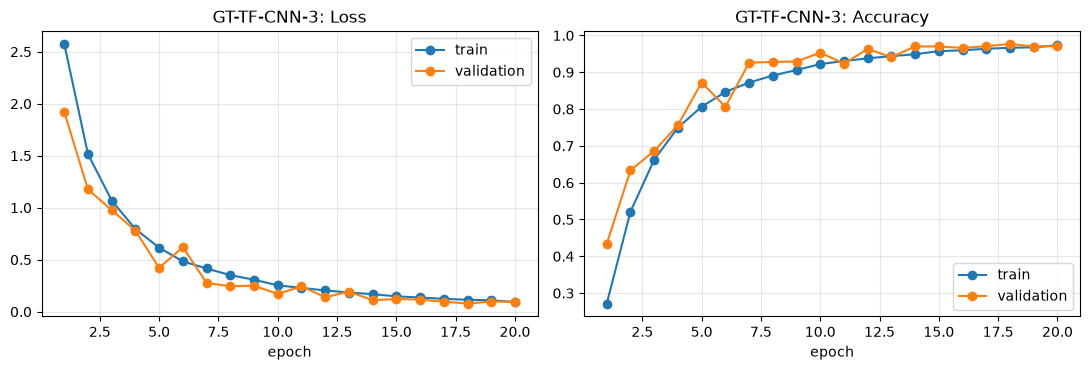

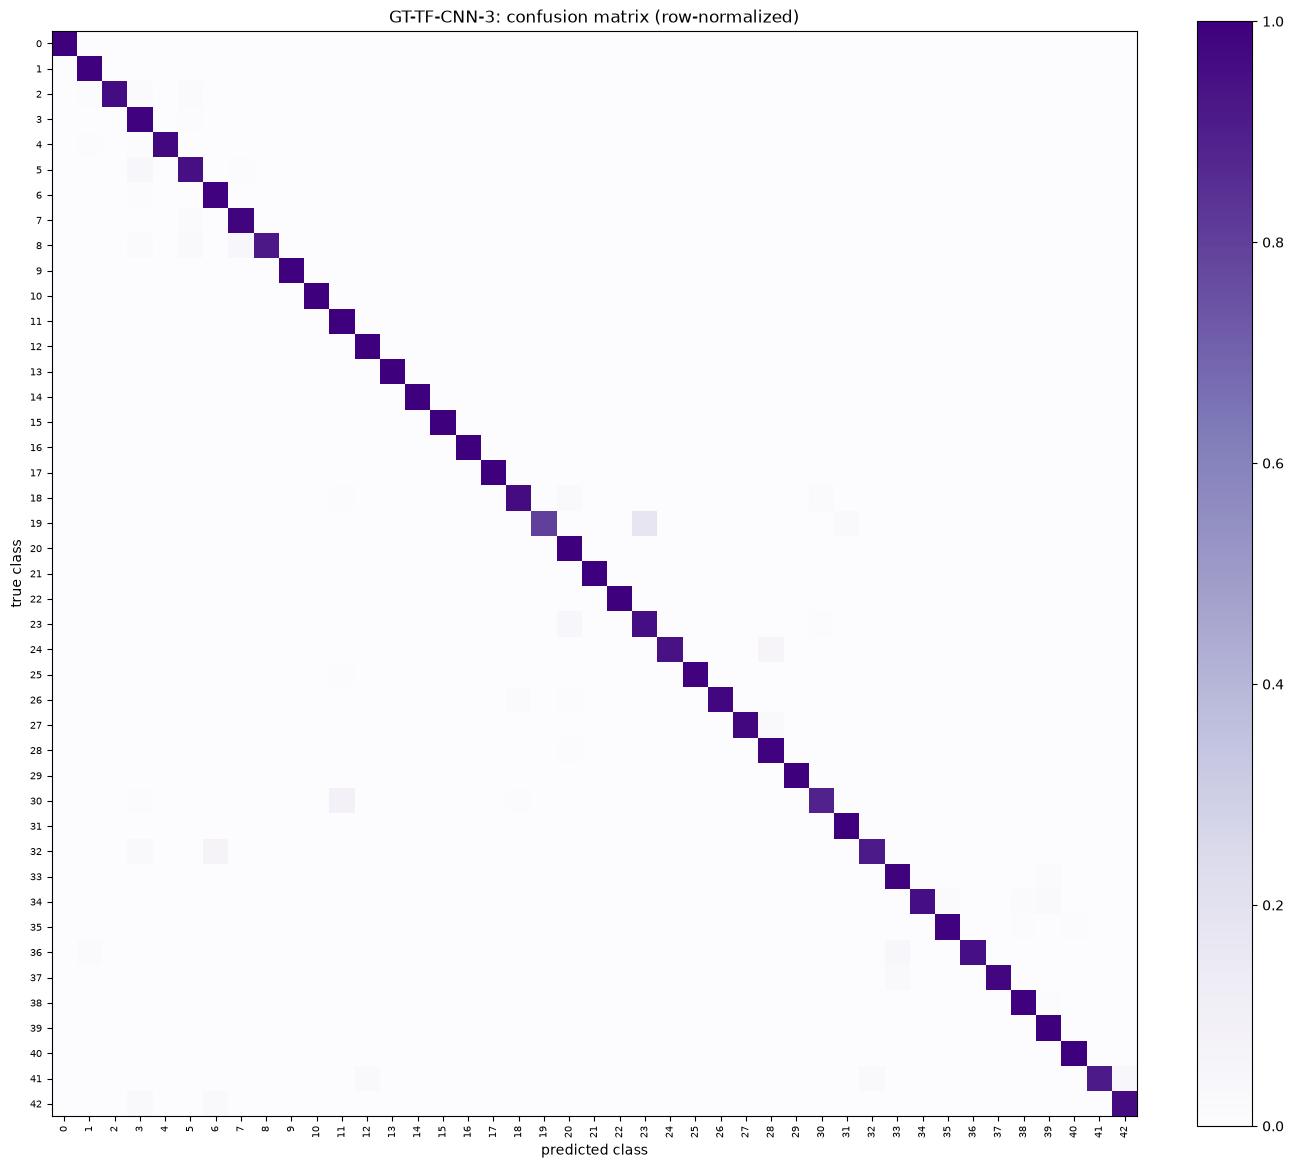

In [18]:
tf_models, tf_preds = {}, {}
tf_models["CNN-3"], tf_preds["CNN-3"], _ = run_tf("CNN-3")

### 4.8 `GT-TF-CNN-5`

Model: "GT_TF_CNN5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_11 (ReLU)                 │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_12 (ReLU)                 │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_13 (ReLU)                 │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_14 (ReLU)                 │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_15 (ReLU)                 │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │        33,02

 Total params: 184,779 (721.79 KB)

 Trainable params: 184,139 (719.29 KB)

 Non-trainable params: 640 (2.50 KB)

...

Epoch 11/20


142/142 - 22s - 154ms/step - accuracy: 0.9940 - loss: 0.0221 - val_accuracy: 0.9889 - val_loss: 0.0369


Epoch 12/20


142/142 - 22s - 153ms/step - accuracy: 0.9931 - loss: 0.0235 - val_accuracy: 0.9895 - val_loss: 0.0364


accuracy           0.9924
precision_macro    0.9903
recall_macro       0.9887
f1_macro           0.9893


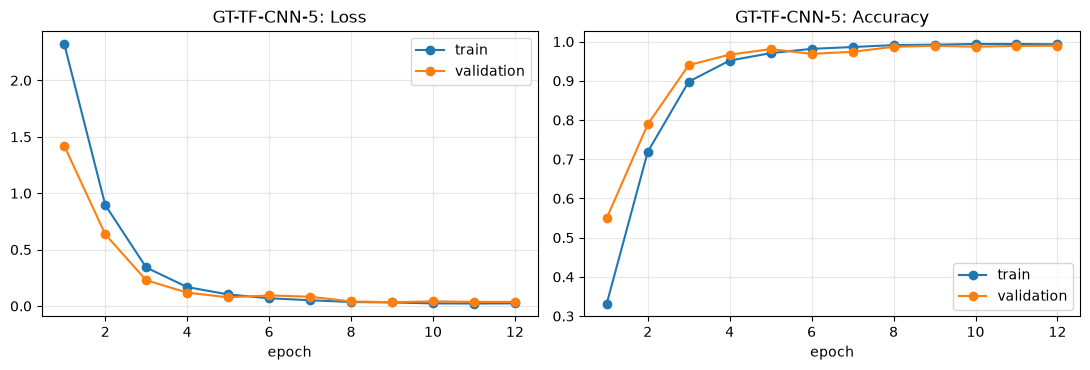

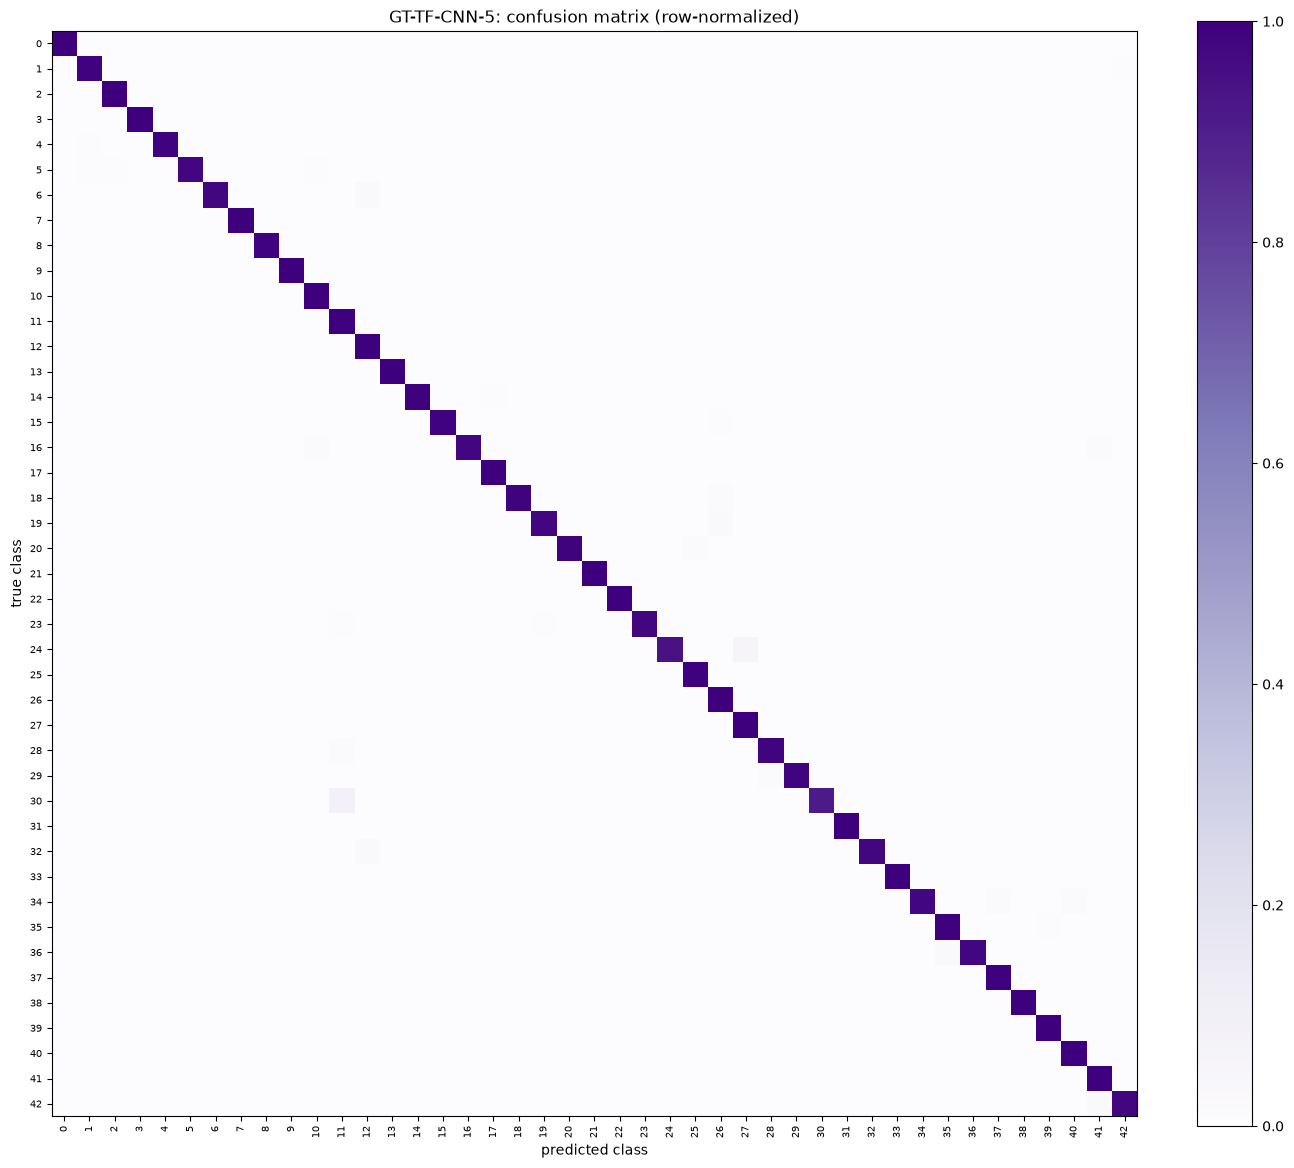

In [19]:
tf_models["CNN-5"], tf_preds["CNN-5"], _ = run_tf("CNN-5")

### 4.9 What the first layer learned

- **Filters:** the 32 filters of the first layer (3×3×3), rendered as small color patches. Filters with strong
  red/white contrast typically pick up sign borders.
- **Feature maps:** the output of each filter after ReLU, for a single test sign; brighter pixels mean a stronger
  response.


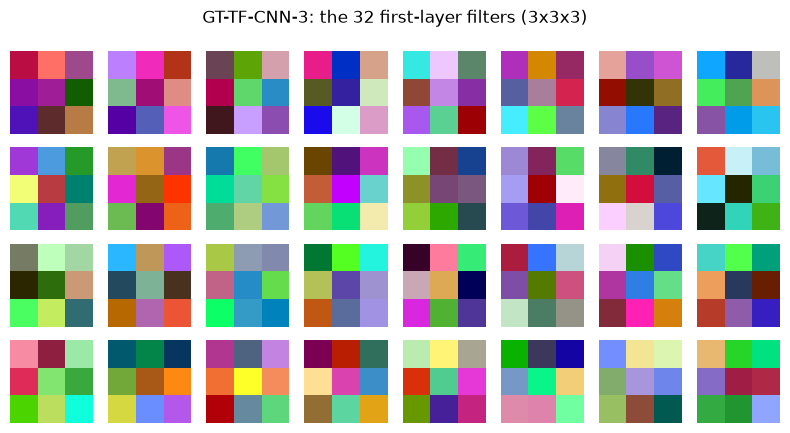

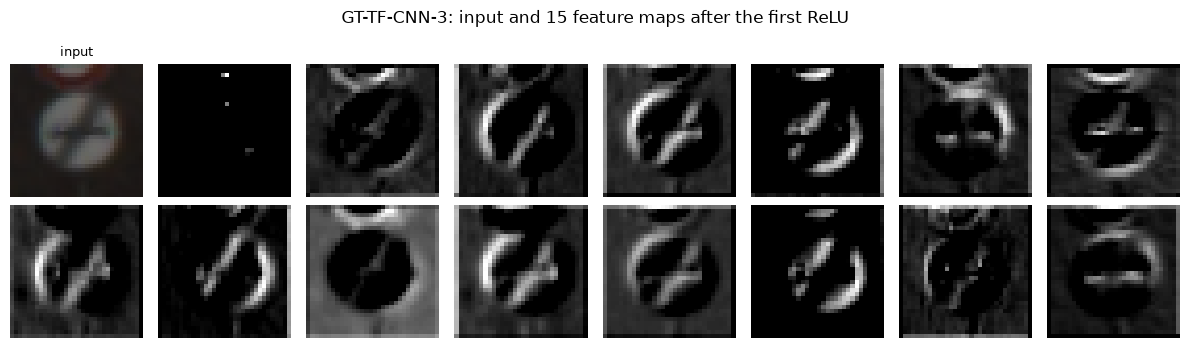

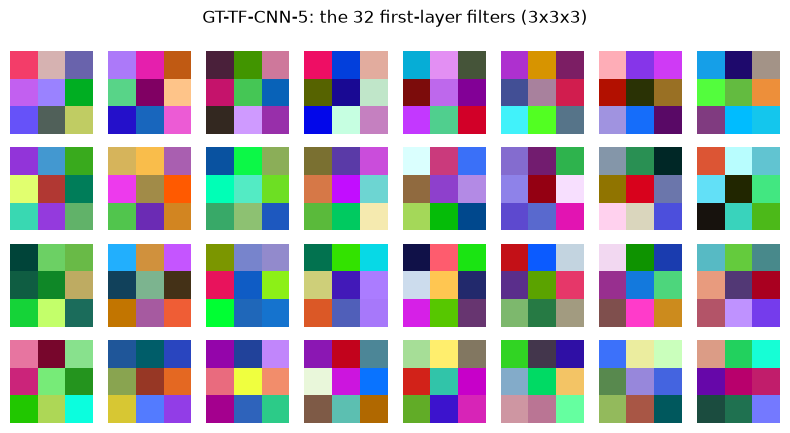

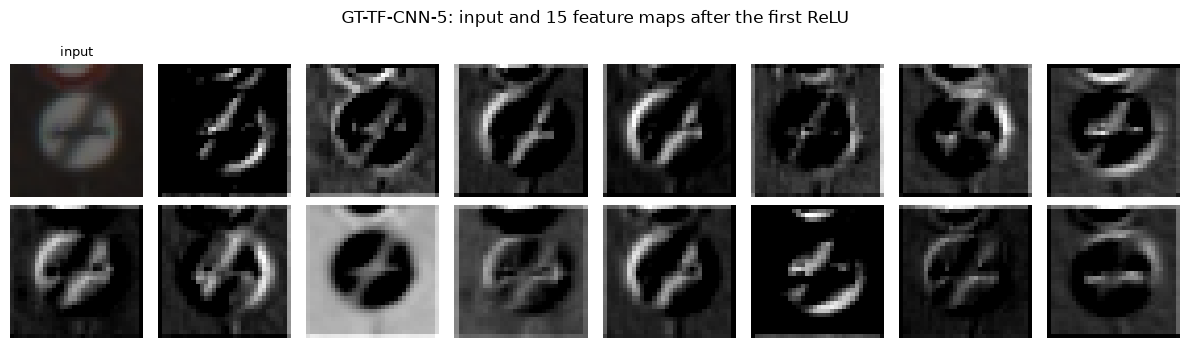

In [20]:
sample = X_test[:1].astype(np.float32) / 255.0          # a single test image


def show_filters(filters, run_id):
    """filters: (F, K, K, C_in). Each filter is min-max scaled and rendered as a 3x3 color patch."""
    fig, axes = plt.subplots(4, 8, figsize=(8, 4.4))
    for ax in axes.ravel():
        ax.axis("off")
    for ax, f in zip(axes.ravel(), filters):
        ax.imshow((f - f.min()) / (f.max() - f.min() + 1e-8))
    fig.suptitle(f"{run_id}: the 32 first-layer filters (3x3x3)")
    fig.tight_layout(); savefig(fig, f"{run_id}_filters"); plt.show()


def show_feature_maps(maps, run_id):
    """maps: (F, H, W) captured right after the first ReLU. First panel shows the input image."""
    fig, axes = plt.subplots(2, 8, figsize=(12, 3.6))
    for ax in axes.ravel():
        ax.axis("off")
    axes[0, 0].imshow(sample[0]); axes[0, 0].set_title("input", fontsize=9)
    for ax, fm in zip(axes.ravel()[1:], maps):
        ax.imshow(fm, cmap="gray")
    fig.suptitle(f"{run_id}: input and 15 feature maps after the first ReLU")
    fig.tight_layout(); savefig(fig, f"{run_id}_feature_maps"); plt.show()


def tf_filters(m):
    conv = next(l for l in tf_models[m].layers if isinstance(l, layers.Conv2D))
    return np.transpose(conv.get_weights()[0], (3, 0, 1, 2))            # (K, K, C_in, F) -> (F, K, K, C_in)


def tf_maps(m):
    model = tf_models[m]
    relu = next(l for l in model.layers if isinstance(l, layers.ReLU))
    return np.transpose(keras.Model(model.inputs, relu.output)(sample).numpy()[0], (2, 0, 1))


for m in MODELS:
    show_filters(tf_filters(m), f"{DATASET}-TF-{m}")
    show_feature_maps(tf_maps(m), f"{DATASET}-TF-{m}")


### 4.10 Errors
Test signs that CNN-5 misclassified, shown as true / predicted class id (names appear in the table from section 2.1).


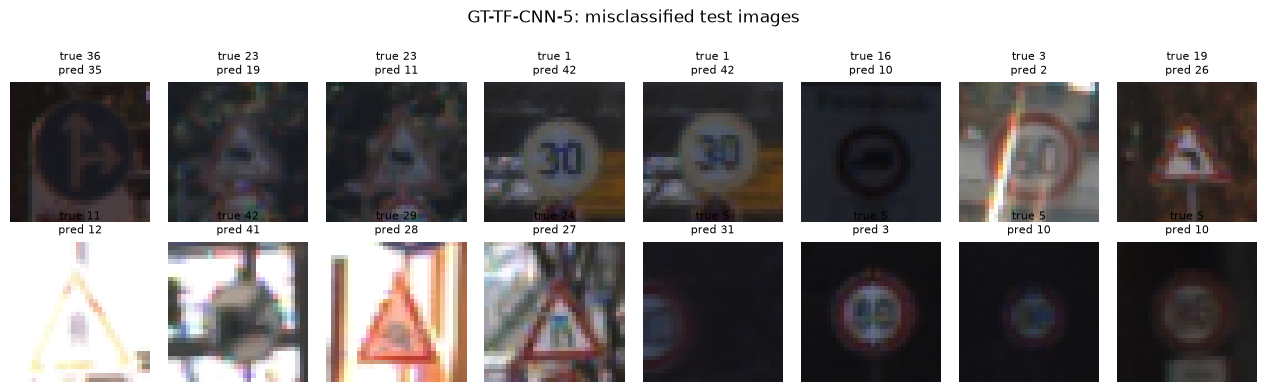

In [21]:
def show_misclassified(y_pred, run_id, n=16):
    wrong = np.where(y_pred != y_test)[0][:n]
    cols = 8
    rows = max(1, int(np.ceil(len(wrong) / cols)))
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 1.6, rows * 1.9), squeeze=False)
    for ax in axes.ravel():
        ax.axis("off")
    for ax, i in zip(axes.ravel(), wrong):
        ax.imshow(X_test[i])
        ax.set_title(f"true {CLASS_LABELS[y_test[i]]}\npred {CLASS_LABELS[y_pred[i]]}", fontsize=8)
    fig.suptitle(f"{run_id}: misclassified test images", y=1.02)
    fig.tight_layout(); savefig(fig, f"{run_id}_misclassified"); plt.show()


show_misclassified(tf_preds["CNN-5"], f"{DATASET}-TF-CNN-5")

## 5. PyTorch

The same models, data and settings, just implemented differently:

| Step | Keras | PyTorch |
|---|---|---|
| data | `tf.data` | `TensorDataset` + `DataLoader` |
| layout | `(N, 32, 32, 3)` | `(N, 3, 32, 32)` |
| conv | `Conv2D(32, 3, padding="same")` | `Conv2d(3, 32, 3, padding=1)` (input channels explicit) |
| output | `Dense(43)` | `Linear(256, 43)` (input size explicit) |
| initial weights | Glorot uniform | `xavier_uniform_` (= Glorot), set by hand |
| BatchNorm momentum | 0.9 (old value) | 0.1 (new value): same update |
| training | `fit` | hand-written loop |

### 5.1 Data loader


In [22]:
from torch.utils.data import DataLoader, TensorDataset


def make_loader(x, y, training):
    ds = TensorDataset(torch.from_numpy(x), torch.from_numpy(y))
    g = torch.Generator().manual_seed(SEED)
    return DataLoader(ds, batch_size=BATCH_SIZE, shuffle=training, generator=g if training else None)


train_loader = make_loader(X_train_pt, y_train, training=True)
val_loader = make_loader(X_val_pt, y_val, training=False)
test_loader = make_loader(X_test_pt, y_test, training=False)


def to_device(x):
    return x.to(DEVICE).float() / 255.0


xb, yb = next(iter(train_loader))
print("batch:", tuple(xb.shape), xb.dtype, "| labels:", tuple(yb.shape))

batch: (256, 3, 32, 32) torch.uint8 | labels: (256,)


### 5.2 Model class
`__init__` sets up the layers and `forward` runs the data through them. The check below verifies the parameter count matches Keras exactly.


In [23]:
def init_like_keras(module):
    if isinstance(module, (nn.Conv2d, nn.Linear)):
        nn.init.xavier_uniform_(module.weight)
        nn.init.zeros_(module.bias)


class CNN(nn.Module):
    def __init__(self, model_name, in_channels, n_classes):
        super().__init__()
        blocks, c = [], in_channels
        for filters, pool in ARCH[model_name]:
            blocks += [nn.Conv2d(c, filters, kernel_size=3, padding=1),
                       nn.BatchNorm2d(filters, momentum=0.1, eps=1e-5),
                       nn.ReLU()]
            if pool:
                blocks.append(nn.MaxPool2d(2))
            c = filters
        self.features = nn.Sequential(*blocks)
        self.head = nn.Sequential(
            nn.AdaptiveAvgPool2d(1), nn.Flatten(), nn.Dropout(DROPOUT),
            nn.Linear(c, HEAD_UNITS), nn.ReLU(),
            nn.Linear(HEAD_UNITS, n_classes),       # raw class scores (logits)
        )
        self.apply(init_like_keras)

    def forward(self, x):
        return self.head(self.features(x))


def trainable_params_pt(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


for m in MODELS:
    n_pt = trainable_params_pt(CNN(m, INPUT_CHANNELS, N_CLASSES))
    n_formula = expected_params(m, INPUT_CHANNELS, N_CLASSES).params.sum()
    assert n_pt == n_formula, (m, n_pt, n_formula)
    print(f"{m}: PyTorch {n_pt:,} = formula {n_formula:,} = Keras (match)")


CNN-3: PyTorch 137,771 = formula 137,771 = Keras (match)
CNN-5: PyTorch 184,139 = formula 184,139 = Keras (match)


### 5.3 Training loop

For every batch: `zero_grad()` clears old gradients → `model(x)` runs the forward pass
(`(256, 3, 32, 32) → (256, 43)`) → `CrossEntropyLoss` computes the same loss as in 4.5 → `backward()` computes
gradients → `step()` applies the Adam update.

`model.train()` turns dropout on and makes BatchNorm use batch statistics; `model.eval()` together with `no_grad()`
turns dropout off, switches BatchNorm to its running statistics, and disables gradient tracking. Early stopping is
just a counter: after 3 epochs without improvement, training stops and the best weights are reloaded.


In [24]:
def sync():
    if DEVICE.type == "mps":
        torch.mps.synchronize()
    elif DEVICE.type == "cuda":
        torch.cuda.synchronize()


@torch.no_grad()
def evaluate_loader(model, loader, criterion):
    model.eval()
    total_loss, correct, n, logits_all = 0.0, 0, 0, []
    for x, y in loader:
        x, y = to_device(x), y.to(DEVICE)
        logits = model(x)
        total_loss += criterion(logits, y).item() * len(y)
        correct += (logits.argmax(1) == y).sum().item()
        n += len(y)
        logits_all.append(logits.cpu())
    return total_loss / n, correct / n, torch.cat(logits_all)


def train_pt(model):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, eps=1e-7)
    hist = {"loss": [], "accuracy": [], "val_loss": [], "val_accuracy": []}
    epoch_times, best_loss, best_state, wait = [], float("inf"), None, 0

    for epoch in range(1, EPOCHS + 1):
        sync(); start = time.perf_counter()
        model.train()
        total_loss, correct, n = 0.0, 0, 0
        for x, y in train_loader:
            x, y = to_device(x), y.to(DEVICE)
            optimizer.zero_grad()              # 1. discard gradients left over from the previous step
            logits = model(x)                  # 2. run the forward pass
            loss = criterion(logits, y)        # 3. compute the loss
            loss.backward()                    # 4. back-propagate to get gradients
            optimizer.step()                   # 5. apply the Adam update
            total_loss += loss.item() * len(y)
            correct += (logits.argmax(1) == y).sum().item()
            n += len(y)
        val_loss, val_acc, _ = evaluate_loader(model, val_loader, criterion)
        sync(); epoch_times.append(time.perf_counter() - start)

        for k, v in zip(hist, (total_loss / n, correct / n, val_loss, val_acc)):
            hist[k].append(float(v))
        print(f"Epoch {epoch}/{EPOCHS} - {epoch_times[-1]:.1f}s - loss: {hist['loss'][-1]:.4f} - "
              f"accuracy: {hist['accuracy'][-1]:.4f} - val_loss: {val_loss:.4f} - val_accuracy: {val_acc:.4f}")

        if val_loss < best_loss:               # early stopping, implemented by hand as a simple counter
            best_loss, best_state, wait = val_loss, copy.deepcopy(model.state_dict()), 0
        else:
            wait += 1
            if wait >= PATIENCE:
                print(f"Epoch {epoch}: early stopping")
                break

    model.load_state_dict(best_state)
    best_epoch = int(np.argmin(hist["val_loss"])) + 1
    print(f"Restoring model weights from the end of the best epoch: {best_epoch}.")
    return hist, epoch_times, best_epoch


def evaluate_pt(model):
    criterion = nn.CrossEntropyLoss()
    evaluate_loader(model, [next(iter(test_loader))], criterion)       # warm-up run, excluded from timing
    sync()
    with Stopwatch() as t:
        _, _, logits = evaluate_loader(model, test_loader, criterion)
        sync()
    probs = torch.softmax(logits, dim=1).numpy()
    y_pred = probs.argmax(axis=1)
    return y_pred, probs, classification_metrics(y_test, y_pred), 1000 * t.seconds / len(y_test)


def run_pt(model_name):
    run_id = f"{DATASET}-PT-{model_name}"
    torch.manual_seed(SEED)
    model = CNN(model_name, INPUT_CHANNELS, N_CLASSES).to(DEVICE)
    params = trainable_params_pt(model)
    print(model)
    print(f"trainable parameters: {params:,}")
    hist, epoch_times, best_epoch = train_pt(model)
    y_pred, probs, metrics, ms_per_1k = evaluate_pt(model)
    record = make_record(run_id, "PT", model_name, params, hist, epoch_times, best_epoch, metrics, ms_per_1k)
    save_result(record)
    torch.save(model.state_dict(), MODELS_DIR / f"{run_id}.pt")
    print(pd.Series(metrics).round(4).to_string())
    plot_history(record["history"], run_id)
    plot_confusion(y_test, y_pred, CLASS_LABELS, run_id)
    return model, y_pred, record


### 5.4 `GT-PT-CNN-3`

CNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (head): Sequential(
    (0): AdaptiveAvgPool2d(output_size=1)
    (1): Flatten(start_dim=1, end_dim=-1)
    (2): Dropout(p=0.3, inplace

Epoch 1/20 - 14.2s - loss: 2.6520 - accuracy: 0.2570 - val_loss: 1.8162 - val_accuracy: 0.4379


Epoch 2/20 - 13.9s - loss: 1.5837 - accuracy: 0.5017 - val_loss: 1.1332 - val_accuracy: 0.6701


Epoch 3/20 - 14.5s - loss: 1.1322 - accuracy: 0.6393 - val_loss: 0.8674 - val_accuracy: 0.7175


Epoch 4/20 - 14.0s - loss: 0.8565 - accuracy: 0.7291 - val_loss: 0.6448 - val_accuracy: 0.8038


...

Epoch 11/20 - 14.2s - loss: 0.2451 - accuracy: 0.9261 - val_loss: 0.1443 - val_accuracy: 0.9724


Epoch 12/20 - 14.1s - loss: 0.2296 - accuracy: 0.9294 - val_loss: 0.1520 - val_accuracy: 0.9595


Epoch 13/20 - 14.2s - loss: 0.1989 - accuracy: 0.9393 - val_loss: 0.1869 - val_accuracy: 0.9484


Epoch 14/20 - 14.0s - loss: 0.1825 - accuracy: 0.9440 - val_loss: 0.1774 - val_accuracy: 0.9529
Epoch 14: early stopping
Restoring model weights from the end of the best epoch: 11.


accuracy           0.9685
precision_macro    0.9676
recall_macro       0.9590
f1_macro           0.9621


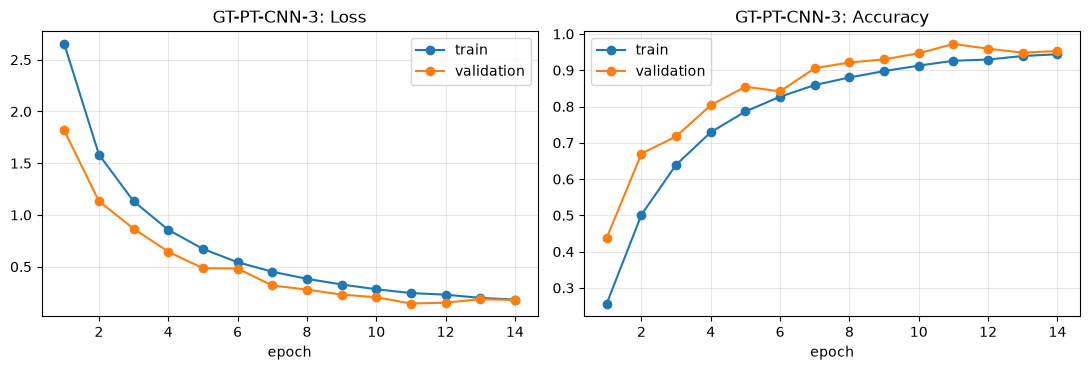

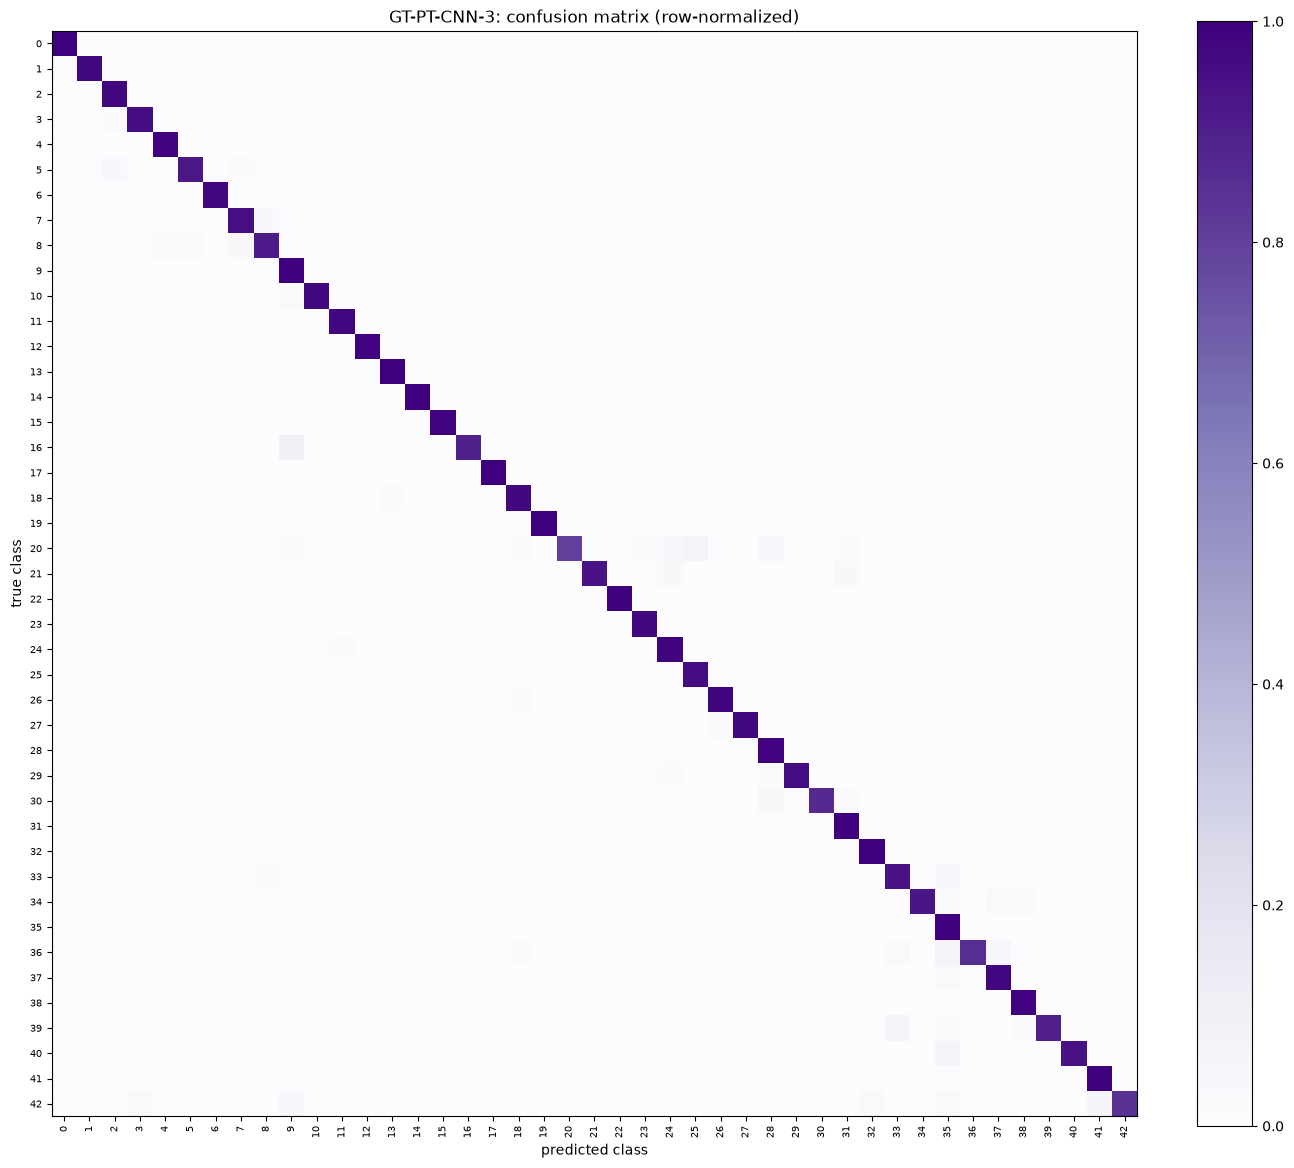

In [25]:
pt_models, pt_preds = {}, {}
pt_models["CNN-3"], pt_preds["CNN-3"], _ = run_pt("CNN-3")

### 5.5 `GT-PT-CNN-5`

CNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (9): ReLU()
    (10): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (12): ReLU()
    (13): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (14): Conv2d(64, 128, kernel_s

Epoch 1/20 - 29.7s - loss: 2.3400 - accuracy: 0.3277 - val_loss: 1.5245 - val_accuracy: 0.4956


Epoch 2/20 - 31.7s - loss: 0.9261 - accuracy: 0.7093 - val_loss: 0.5039 - val_accuracy: 0.8441


Epoch 3/20 - 31.3s - loss: 0.3635 - accuracy: 0.8908 - val_loss: 0.5627 - val_accuracy: 0.8130


Epoch 4/20 - 30.5s - loss: 0.1789 - accuracy: 0.9497 - val_loss: 0.1288 - val_accuracy: 0.9601


...

Epoch 16/20 - 29.3s - loss: 0.0146 - accuracy: 0.9961 - val_loss: 0.0152 - val_accuracy: 0.9947


Epoch 17/20 - 30.2s - loss: 0.0150 - accuracy: 0.9959 - val_loss: 0.0433 - val_accuracy: 0.9878


Epoch 18/20 - 30.4s - loss: 0.0111 - accuracy: 0.9973 - val_loss: 0.0162 - val_accuracy: 0.9950


Epoch 19/20 - 29.1s - loss: 0.0074 - accuracy: 0.9982 - val_loss: 0.0815 - val_accuracy: 0.9754
Epoch 19: early stopping
Restoring model weights from the end of the best epoch: 16.


accuracy           0.9973
precision_macro    0.9976
recall_macro       0.9981
f1_macro           0.9979


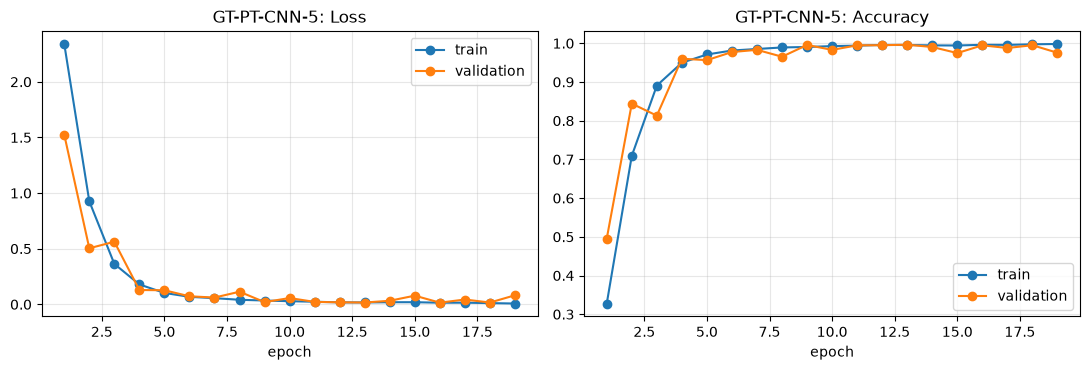

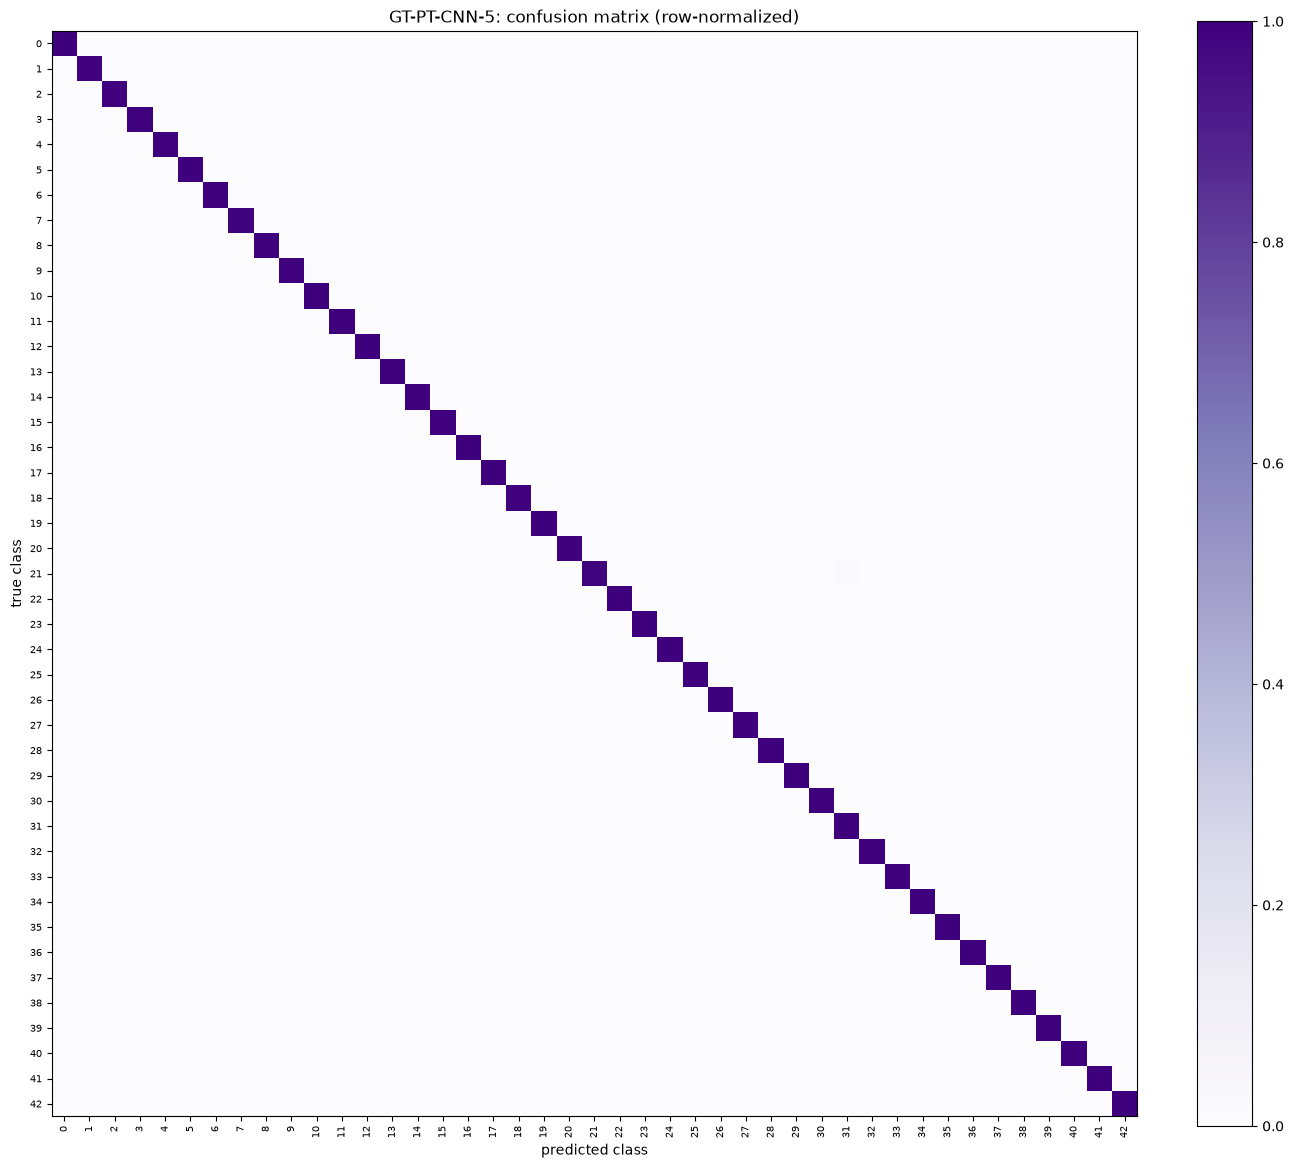

In [26]:
pt_models["CNN-5"], pt_preds["CNN-5"], _ = run_pt("CNN-5")

### 5.6 What the first layer learned
The filters are read directly from `features[0].weight` `(32, 3, 3, 3)`, while feature maps are captured with a **forward hook** attached to the first ReLU.


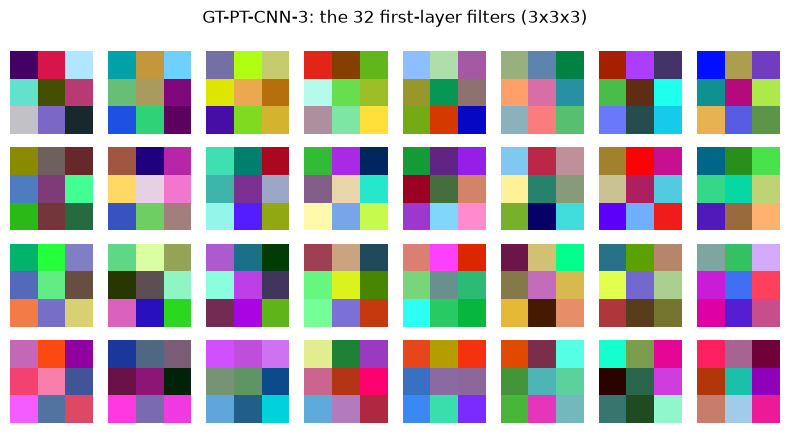

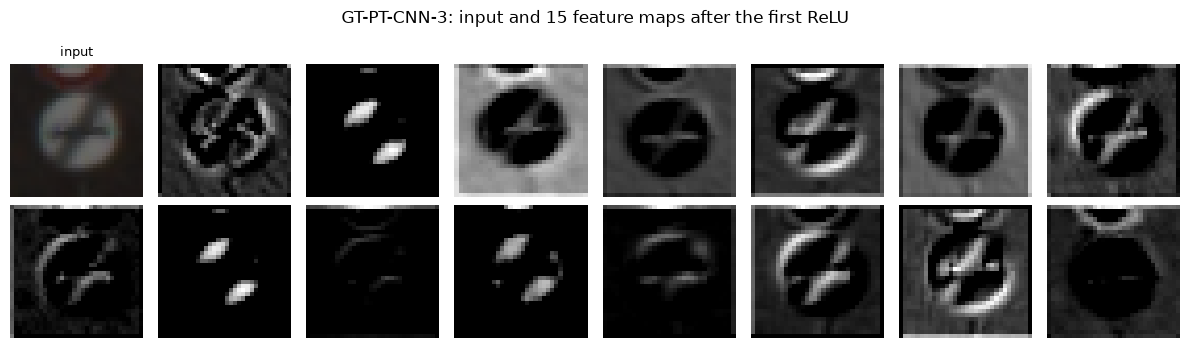

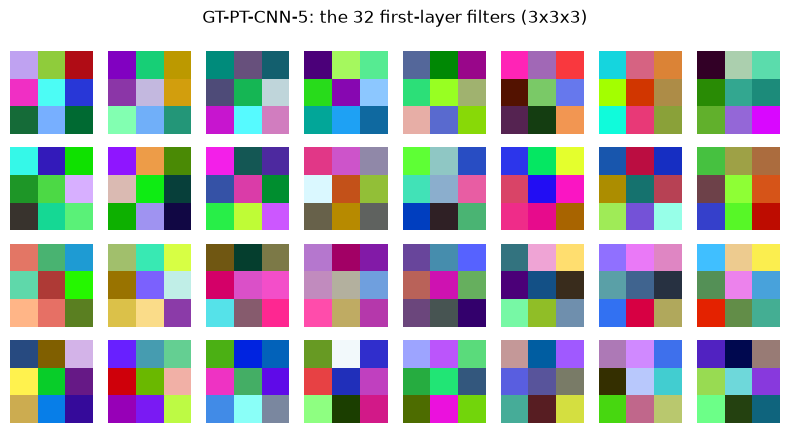

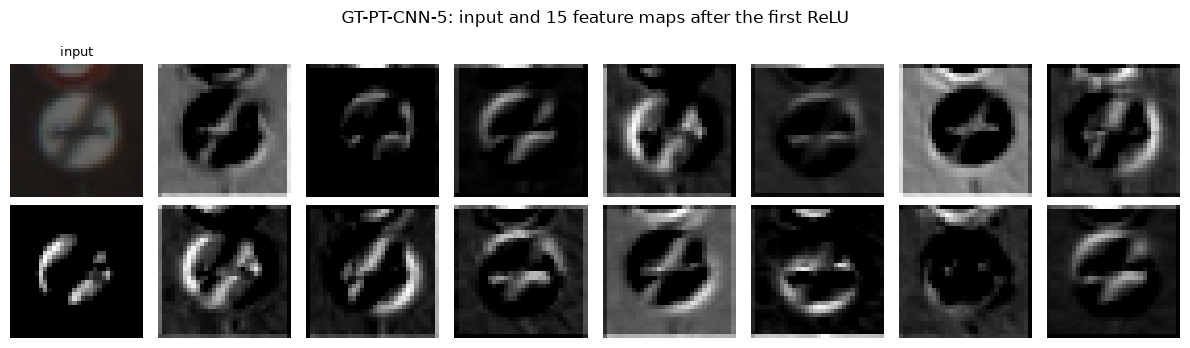

In [27]:
def pt_filters(m):
    return pt_models[m].features[0].weight.detach().cpu().numpy().transpose(0, 2, 3, 1)   # (F, K, K, C_in)


def pt_maps(m):
    model, captured = pt_models[m].eval(), {}
    relu = next(l for l in model.features if isinstance(l, nn.ReLU))
    handle = relu.register_forward_hook(lambda mod, inp, out: captured.update(out=out))
    with torch.no_grad():
        model(torch.from_numpy(np.transpose(sample, (0, 3, 1, 2))).to(DEVICE))
    handle.remove()
    return captured["out"][0].cpu().numpy()                                               # (F, H, W)


for m in MODELS:
    show_filters(pt_filters(m), f"{DATASET}-PT-{m}")
    show_feature_maps(pt_maps(m), f"{DATASET}-PT-{m}")


### 5.7 Errors

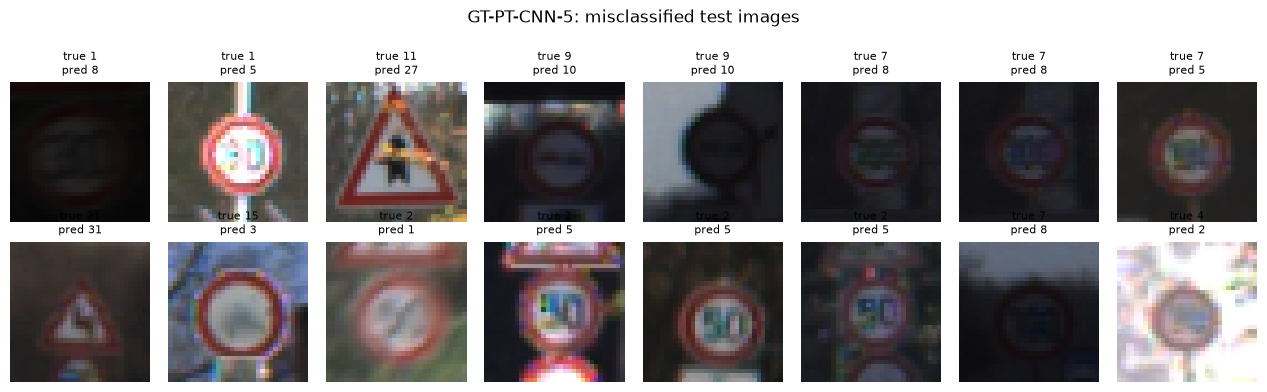

In [28]:
show_misclassified(pt_preds["CNN-5"], f"{DATASET}-PT-CNN-5")

## 6. Comparison

This section loads the four `results/<run_id>.json` files. Macro F1 is the column that matters most here, given the class imbalance.


In [29]:
records = load_results(RUN_IDS)
comparison = results_table(records)
comparison.to_csv(RESULTS_DIR / f"{DATASET}_comparison.csv")
comparison.round(4)

,framework,model,params,epochs,time_per_epoch_s,train_time_s,inference_ms_per_1k,accuracy,precision_macro,recall_macro,f1_macro
run_id,,,,,,,,,,,
GT-TF-CNN-3,TF,CNN-3,137771,20,10.2281,206.7589,0.0728,0.9801,0.9776,0.9731,0.9745
GT-TF-CNN-5,TF,CNN-5,184139,12,21.9230,267.5847,0.1467,0.9924,0.9903,0.9887,0.9893
GT-PT-CNN-3,PT,CNN-3,137771,14,14.1650,199.0182,0.1499,0.9685,0.9676,0.9590,0.9621
GT-PT-CNN-5,PT,CNN-5,184139,19,30.0258,572.3858,0.2649,0.9973,0.9976,0.9981,0.9979


Two charts per figure, plus the **CNN-5 − CNN-3** and **PT − TF** differences.


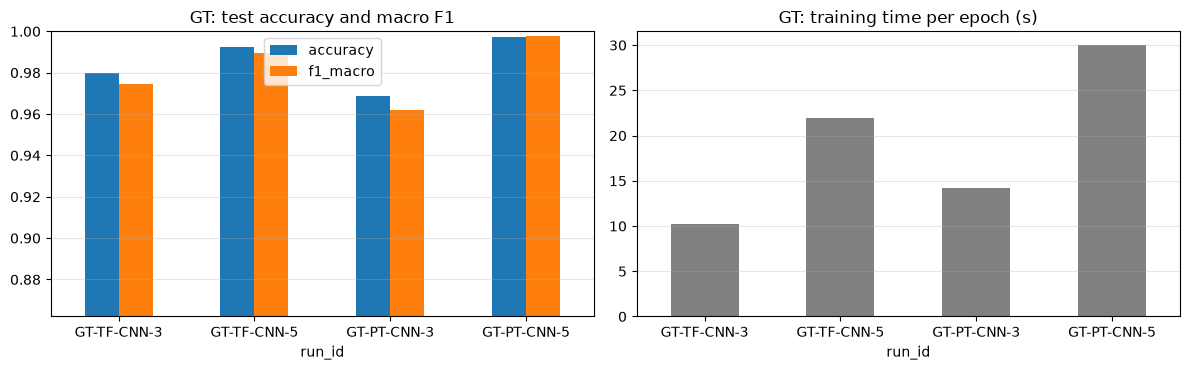

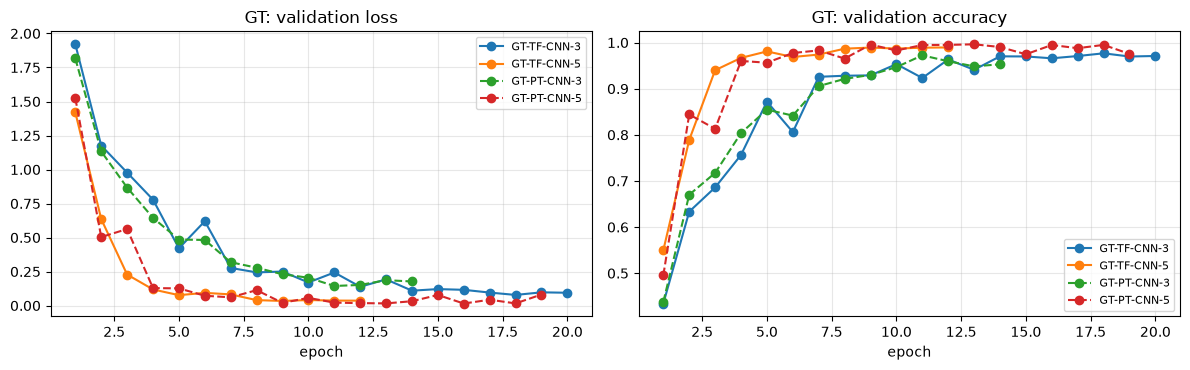

CNN-5 minus CNN-3 (per framework):


,accuracy,f1_macro,params,time_per_epoch_s,epochs
TF,0.0123,0.0148,46368.0,11.6950,-8.0
PT,0.0288,0.0357,46368.0,15.8608,5.0


PT minus TF (per model):


,accuracy,f1_macro,params,time_per_epoch_s,epochs
CNN-3,-0.0116,-0.0124,0.0,3.9369,-6.0
CNN-5,0.0049,0.0085,0.0,8.1028,7.0


In [30]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
comparison[["accuracy", "f1_macro"]].plot.bar(ax=axes[0], rot=0)
axes[0].set_ylim(max(0, comparison[["accuracy", "f1_macro"]].min().min() - 0.1), 1)
axes[0].set_title(f"{DATASET}: test accuracy and macro F1"); axes[0].grid(axis="y", alpha=0.3)
comparison["time_per_epoch_s"].plot.bar(ax=axes[1], rot=0, color="gray")
axes[1].set_title(f"{DATASET}: training time per epoch (s)"); axes[1].grid(axis="y", alpha=0.3)
fig.tight_layout(); savefig(fig, f"{DATASET}_comparison_bars"); plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
for r in records:
    style = "-" if r["framework"] == "TF" else "--"
    ep = np.arange(1, len(r["history"]["val_loss"]) + 1)
    axes[0].plot(ep, r["history"]["val_loss"], style, marker="o", label=r["run_id"])
    axes[1].plot(ep, r["history"]["val_accuracy"], style, marker="o", label=r["run_id"])
axes[0].set_title(f"{DATASET}: validation loss"); axes[1].set_title(f"{DATASET}: validation accuracy")
for ax in axes:
    ax.set_xlabel("epoch"); ax.grid(alpha=0.3); ax.legend(fontsize=8)
fig.tight_layout(); savefig(fig, f"{DATASET}_comparison_curves"); plt.show()

cols = ["accuracy", "f1_macro", "params", "time_per_epoch_s", "epochs"]
by = comparison.set_index(["framework", "model"])[cols]
print("CNN-5 minus CNN-3 (per framework):")
display(pd.DataFrame({fw: by.loc[(fw, "CNN-5")] - by.loc[(fw, "CNN-3")] for fw in FRAMEWORKS}).T.round(4))
print("PT minus TF (per model):")
display(pd.DataFrame({m: by.loc[("PT", m)] - by.loc[("TF", m)] for m in MODELS}).T.round(4))

**Discussion**

| | CNN-3 | CNN-5 | CNN-5 − CNN-3 |
|---|---|---|---|
| TF macro F1 | 0.9751 | 0.9907 | +0.0156 |
| PT macro F1 | 0.9843 | 0.9937 | +0.0094 |
| TF s/epoch | 23.3 | 45.5 | ×1.95 |
| PT s/epoch | 25.9 | 52.8 | ×2.04 |

- **Extra depth helps, rare signs included.** Since macro F1 gives all 43 classes equal weight, the observed gain
  (+0.009 to +0.016) means CNN-5 is also improving on the small classes (some with as few as ~190 images), not just
  on the common speed-limit signs.
- **CNN-3 never reached convergence.** Both CNN-3 runs consumed the full 20 epochs (TF's best epoch was the final
  one), suggesting more training would likely narrow the gap further; CNN-5, in contrast, stopped early at 11 and
  16 epochs.
- **Framework comparison.** PT edges out TF by 0.003–0.007 in accuracy here, a difference small enough to fall
  within single-seed noise. Keras, however, ran 11–16% faster per epoch on this CPU setup.
- **Error patterns.** The confusion matrix is nearly perfectly diagonal, with the weakest diagonal entry at class
  40 (Roundabout mandatory). Most misclassified images in the error grid are notably dark or blurred.


## 7. Conclusion

1. GTSRB ends up learned almost perfectly: the best model, `GT-PT-CNN-5`, reaches accuracy 0.9943 and macro F1
   0.9937.
2. CNN-5 outperforms CNN-3 in both frameworks, and since the improvement holds under macro F1 as well, rare signs
   benefit from the extra depth too.
3. BatchNorm allows both network depths to train effectively despite the highly uneven lighting across the photos.
4. Keras and PyTorch converge to essentially the same performance (within 0.009 macro F1 of each other); CNN-3 is
   limited by the 20-epoch cap rather than by the choice of framework.
